In [4]:
!pip install numpy==1.26.4

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
%matplotlib inline
matplotlib.rcParams["figure.figsize"] = (20,10)

In [6]:
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.model_selection import train_test_split,KFold,cross_val_score
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [7]:
df=pd.read_csv("combined_with_SoC_from_filename.csv")
print(df.shape)
print(df.head())
print(df.describe())
print(df.isnull().sum())

(10640, 5)
   Frequency(Hz)    R(ohm)    X(ohm)     V(V)  SoC(%)
0           0.01  0.134896 -0.057711  3.28480      45
1           0.02  0.111933 -0.044654  3.28780      45
2           0.03  0.102591 -0.036860  3.28773      45
3           0.05  0.093982 -0.028616  3.28793      45
4           0.08  0.088014 -0.022872  3.28806      45
       Frequency(Hz)        R(ohm)        X(ohm)          V(V)        SoC(%)
count   10640.000000  10640.000000  10640.000000  10640.000000  10640.000000
mean      117.360357      0.078236     -0.015131      3.292226     52.500000
std       246.765692      0.024907      0.031339      0.057496     28.832761
min         0.010000      0.041858     -1.329210      2.988150      5.000000
25%         0.275000      0.061224     -0.014700      3.269110     28.750000
50%         6.500000      0.072583     -0.007150      3.289425     52.500000
75%        85.750000      0.089293     -0.005771      3.326633     76.250000
max      1000.000000      0.389055     -0.000662 

In [8]:
#rename columns to shorter names for easier coding
df=df.rename(columns={
    'Frequency(Hz)': 'freq',
    'R(ohm)': 'R',
    'X(ohm)': 'X',
    'V(V)': 'V',
    'SoC(%)': 'SoC'
})
print(df.columns)

Index(['freq', 'R', 'X', 'V', 'SoC'], dtype='object')


In [9]:
#sorting by soc and freq....this keeps similar soc rows toghther
df=df.sort_values(['SoC','freq']).reset_index(drop=True)
print("unique freq points :",df['freq'].nunique())
print("SoC unique values :",df['SoC'].nunique())
df.head(20)

unique freq points : 28
SoC unique values : 20


,freq,R,X,V,SoC
0,0.01,0.161703,-0.081101,3.19123,5
1,0.01,0.173485,-0.085087,3.19166,5
2,0.01,0.183274,-0.129345,2.98815,5
3,0.01,0.153369,-0.074037,3.19138,5
4,0.01,0.171759,-0.091119,3.17395,5
5,0.01,0.175767,-0.083051,3.19017,5
6,0.01,0.172752,-0.085428,3.18954,5
7,0.01,0.170303,-0.104054,3.08233,5
8,0.01,0.170046,-0.085483,3.18760,5
9,0.01,0.167385,-0.096874,3.14518,5


In [10]:
#creating repeat id as their same freq appears multiple times
df['repeat_id']=df.groupby(['SoC','freq']).cumcount()
counts = df.groupby(['SoC','freq']).size()
print("Counts per(SoC,freq) pair :")
print(counts.value_counts().sort_index())

print(df.head(40))

Counts per(SoC,freq) pair :
19    560
Name: count, dtype: int64
    freq         R         X        V  SoC  repeat_id
0   0.01  0.161703 -0.081101  3.19123    5          0
1   0.01  0.173485 -0.085087  3.19166    5          1
2   0.01  0.183274 -0.129345  2.98815    5          2
3   0.01  0.153369 -0.074037  3.19138    5          3
4   0.01  0.171759 -0.091119  3.17395    5          4
5   0.01  0.175767 -0.083051  3.19017    5          5
6   0.01  0.172752 -0.085428  3.18954    5          6
7   0.01  0.170303 -0.104054  3.08233    5          7
8   0.01  0.170046 -0.085483  3.18760    5          8
9   0.01  0.167385 -0.096874  3.14518    5          9
10  0.01  0.192417 -0.089313  3.17023    5         10
11  0.01  0.173107 -0.083944  3.19156    5         11
12  0.01  0.178099 -0.081704  3.19295    5         12
13  0.01  0.195746 -0.089125  3.18046    5         13
14  0.01  0.182033 -0.104468  3.09408    5         14
15  0.01  0.163900 -0.078576  3.19497    5         15
16  0.01  0.161622

In [11]:
#building spectrum wise dataset
spectrum_rows=[]
for (soc,rep),group_df in df.groupby(['SoC','repeat_id']):
    group_df = group_df.sort_values('freq').reset_index(drop=True)

    if len(group_df) !=28:
        print(f"problem found: SoC = {soc},repeat_id={rep},rows={len(group_df)}")
        continue
    row_dict={}
    row_dict['SoC']=soc
    row_dict['repeat_id']=rep

    for i,row in enumerate(group_df.itertuples(index=False),start=1):
        row_dict[f'freq_{i}'] =row.freq
        row_dict[f'R_{i}'] =row.R
        row_dict[f'X_{i}']=row.X
        row_dict[f'V_{i}']=row.V

    spectrum_rows.append(row_dict)
df_spec = pd.DataFrame(spectrum_rows)
df_spec = df_spec.sort_values(['SoC','repeat_id']).reset_index(drop=True)

print("Shape of df_spec:", df_spec.shape)
print("\nUnique SoC values:")
print(sorted(df_spec['SoC'].unique()))

print("\nSamples per SoC:")
print(df_spec['SoC'].value_counts().sort_index())

print("\nFirst 5 rows of df_spec:")
print(df_spec.head())

    

Shape of df_spec: (380, 114)

Unique SoC values:
[5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]

Samples per SoC:
SoC
5      19
10     19
15     19
20     19
25     19
30     19
35     19
40     19
45     19
50     19
55     19
60     19
65     19
70     19
75     19
80     19
85     19
90     19
95     19
100    19
Name: count, dtype: int64

First 5 rows of df_spec:
   SoC  repeat_id  freq_1       R_1       X_1      V_1  freq_2       R_2  \
0    5          0    0.01  0.161703 -0.081101  3.19123    0.02  0.133373   
1    5          1    0.01  0.173485 -0.085087  3.19166    0.02  0.143835   
2    5          2    0.01  0.183274 -0.129345  2.98815    0.02  0.154531   
3    5          3    0.01  0.153369 -0.074037  3.19138    0.02  0.128052   
4    5          4    0.01  0.171759 -0.091119  3.17395    0.02  0.142819   

        X_2      V_2  ...      X_26     V_26  freq_27      R_27      X_27  \
0 -0.060730  3.19588  ... -0.004024  3.19741    810.0  0.04490

In [12]:
X_spec=df_spec.drop(columns=['SoC','repeat_id']+[f'freq_{i}' for i in range(1,29)])
y_spec = df_spec['SoC']
print(X_spec.head())
print(X_spec.shape)
print(y_spec.head())
print(y_spec.shape)

        R_1       X_1      V_1       R_2       X_2      V_2       R_3  \
0  0.161703 -0.081101  3.19123  0.133373 -0.060730  3.19588  0.121210   
1  0.173485 -0.085087  3.19166  0.143835 -0.063538  3.19660  0.131098   
2  0.183274 -0.129345  2.98815  0.154531 -0.083817  2.99496  0.142125   
3  0.153369 -0.074037  3.19138  0.128052 -0.055213  3.19577  0.117091   
4  0.171759 -0.091119  3.17395  0.142819 -0.065911  3.17954  0.130466   

        X_3      V_3       R_4  ...     V_25      R_26      X_26     V_26  \
0 -0.050147  3.19607  0.109562  ...  3.19739  0.046654 -0.004024  3.19741   
1 -0.052625  3.19683  0.118719  ...  3.19816  0.049343 -0.004592  3.19816   
2 -0.065382  2.99957  0.130338  ...  3.00567  0.063886 -0.005655  3.00569   
3 -0.045408  3.19601  0.106680  ...  3.19731  0.052408 -0.003470  3.19731   
4 -0.053788  3.18007  0.118562  ...  3.18191  0.050930 -0.005342  3.18191   

       R_27      X_27     V_27      R_28      X_28     V_28  
0  0.044900 -0.002381  3.19740  0.04

In [13]:
#performing train_test_split
X_train_spec,X_test_spec,y_train_spec,y_test_spec = train_test_split(
    X_spec,y_spec,test_size=0.2,random_state=42,shuffle=True
)
print("X_train_spec shape:", X_train_spec.shape)
print("X_test_spec shape :", X_test_spec.shape)
print("y_train_spec shape:", y_train_spec.shape)
print("y_test_spec shape :", y_test_spec.shape)

X_train_spec shape: (304, 84)
X_test_spec shape : (76, 84)
y_train_spec shape: (304,)
y_test_spec shape : (76,)


In [14]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
et_model = ExtraTreesRegressor(n_estimators=100, random_state=42)
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
ab_model = AdaBoostRegressor(n_estimators=100, random_state=42)

models ={
    'Random Forest': rf_model,
    'Extra Trees': et_model,
    'Gradient Boosting' : gb_model,
    'AdaBoost':ab_model
}
print(models)

{'Random Forest': RandomForestRegressor(random_state=42), 'Extra Trees': ExtraTreesRegressor(random_state=42), 'Gradient Boosting': GradientBoostingRegressor(random_state=42), 'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42)}


In [15]:
predictions = {}
results = []
for name,model in models.items():
    model.fit(X_train_spec,y_train_spec)
    y_pred=model.predict(X_test_spec)
    predictions[name]=y_pred

    mae = mean_absolute_error(y_test_spec,y_pred)
    mse = mean_squared_error(y_test_spec,y_pred)
    rmse = np.sqrt(mse)
    r2=r2_score(y_test_spec,y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

df_results = pd.DataFrame(results)
df_results = df_results.round(4)
df_resutls = df_results.sort_values(by='RMSE').reset_index(drop=True)

print("FInal model comparison table")
print(df_results)

FInal model comparison table
               Model     MAE     MSE    RMSE      R2
0      Random Forest  1.7493  5.8370  2.4160  0.9939
1        Extra Trees  1.4645  4.7271  2.1742  0.9951
2  Gradient Boosting  1.5447  4.4241  2.1033  0.9954
3           AdaBoost  2.2438  8.3340  2.8869  0.9913


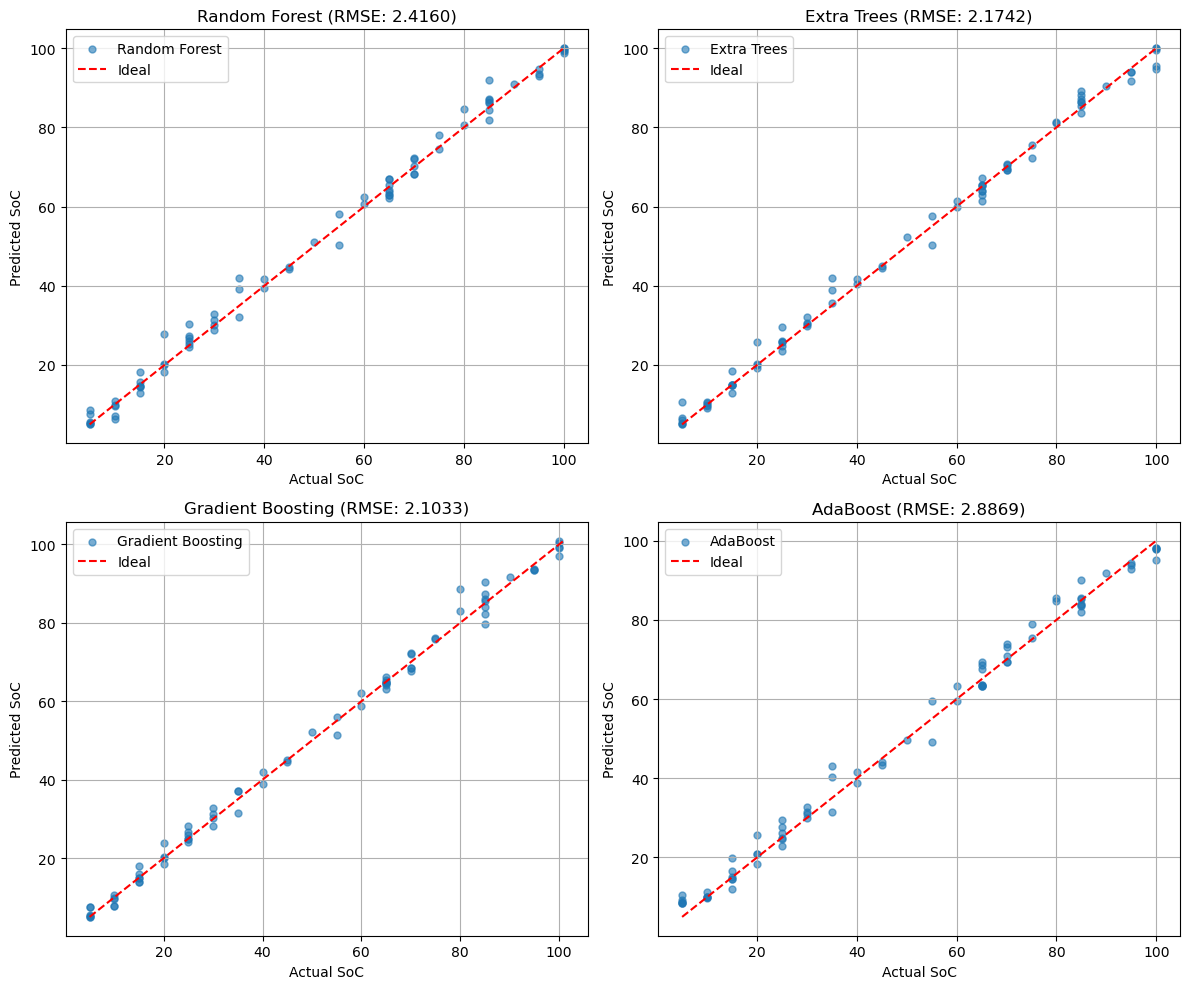

In [16]:
#graph 1 actual vs predicted
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
model_names = ['Random Forest', 'Extra Trees', 'Gradient Boosting', 'AdaBoost']

for ax, name in zip(axes.flatten(), model_names):
    y_pred = predictions[name]
    rmse_val = df_results.loc[df_results['Model'] == name, 'RMSE'].values[0]
    
    ax.scatter(y_test_spec, y_pred, alpha=0.6, s=25, label=name)
               
    min_val = min(y_test_spec.min(), y_pred.min())
    max_val = max(y_test_spec.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal')
    
    ax.set_xlabel('Actual SoC')
    ax.set_ylabel('Predicted SoC')
    ax.set_title(f'{name} (RMSE: {rmse_val:.4f})')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.savefig("actual_vs_predicted_all_models.png",dpi=300,bbox_inches='tight')
plt.show()

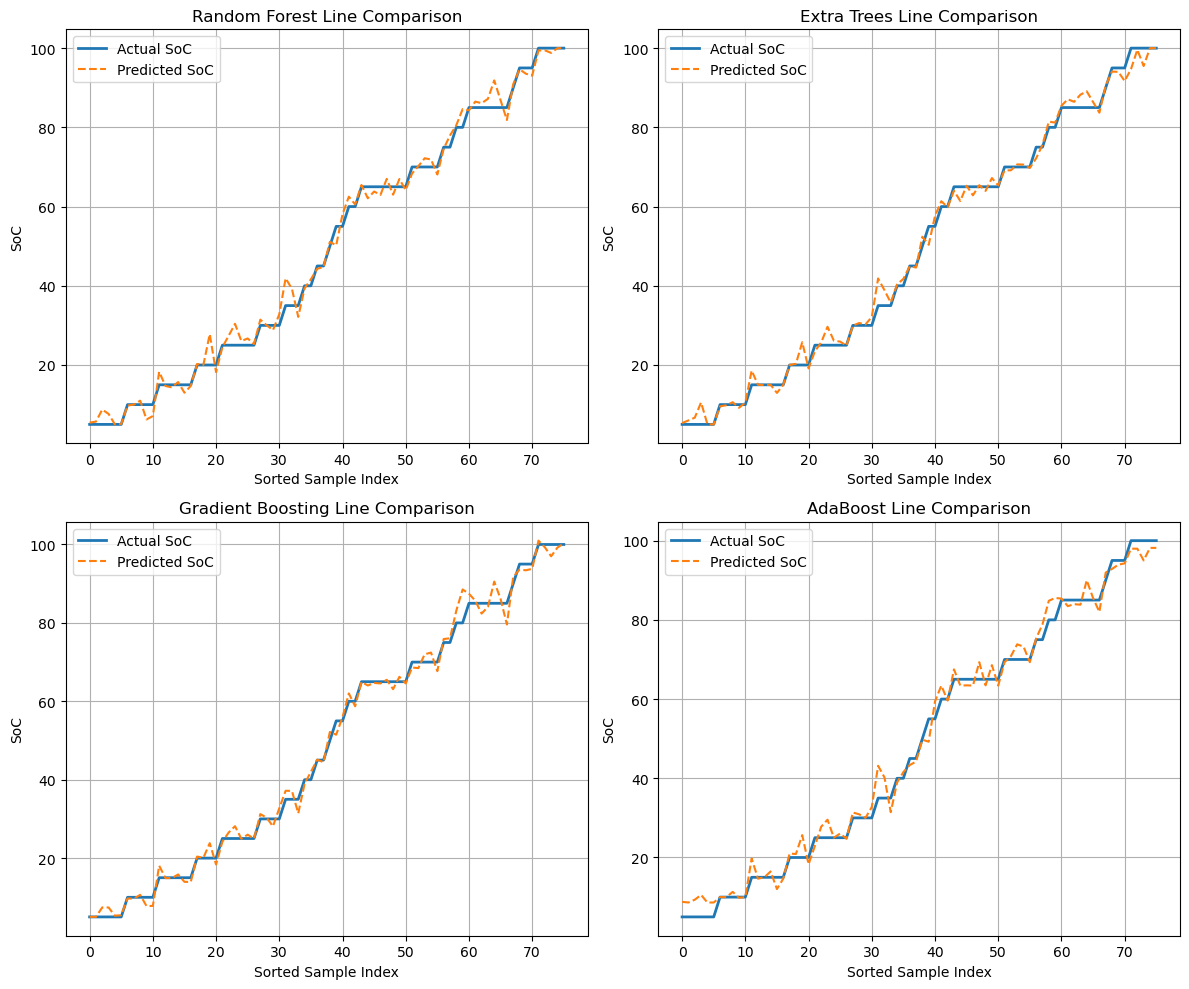

In [17]:
# GRAPH 2
sorted_idx = np.argsort(y_test_spec.values)
y_true_sorted = y_test_spec.values[sorted_idx]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
model_names = ['Random Forest', 'Extra Trees', 'Gradient Boosting', 'AdaBoost']

for ax, name in zip(axes.flatten(), model_names):
    y_pred = predictions[name]
    y_pred_sorted = y_pred[sorted_idx]
    
    ax.plot(y_true_sorted, label='Actual SoC', linewidth=2)
    ax.plot(y_pred_sorted, label='Predicted SoC', linestyle='--')
    ax.set_xlabel('Sorted Sample Index')
    ax.set_ylabel('SoC')
    ax.set_title(f'{name} Line Comparison')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.savefig("Sorted_line_comparison.png",dpi=300,bbox_inches='tight')
plt.show()

In [18]:
#cross validation to check model stability
best_model =GradientBoostingRegressor(n_estimators=100,random_state=42)
kf=KFold(n_splits=5,shuffle=True,random_state=42)

neg_mse_scores =cross_val_score(
    best_model,X_spec,y_spec,cv=kf,scoring='neg_mean_squared_error'
   )
rmse_scores=np.sqrt(-neg_mse_scores)
neg_mae_scores = cross_val_score(
    best_model,
    X_spec,
    y_spec,
    cv=kf,
    scoring='neg_mean_absolute_error'
)
mae_scores = -neg_mae_scores

r2_scores = cross_val_score(
    best_model,
    X_spec,
    y_spec,
    cv=kf,
    scoring='r2'
)

print("Cross-validation results for final model (Gradient Boosting):")
print("CV MAE Mean :", round(mae_scores.mean(), 4))
print("CV MAE Std  :", round(mae_scores.std(), 4))
print("CV RMSE Mean:", round(rmse_scores.mean(), 4))
print("CV RMSE Std :", round(rmse_scores.std(), 4))
print("CV R2 Mean  :", round(r2_scores.mean(), 4))
print("CV R2 Std   :", round(r2_scores.std(), 4))


Cross-validation results for final model (Gradient Boosting):
CV MAE Mean : 1.5163
CV MAE Std  : 0.1454
CV RMSE Mean: 2.074
CV RMSE Std : 0.1968
CV R2 Mean  : 0.9947
CV R2 Std   : 0.0013


In [19]:
#final spectrum_wise dataset as CSV
df_spec.to_csv("Final_spectrum_dataset.csv",index=False)


In [20]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neighbors import  KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [21]:
new_models = {}
new_models["HistGradientBoosting"] = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

new_models["KNN"]=Pipeline([
    ("sclaer",StandardScaler()),
    ("model",KNeighborsRegressor(n_neighbors=5,weights='distance'))
])

new_models["SVR_RBF"] = Pipeline([
    ('scaler',StandardScaler()),
    ('model',MLPRegressor(
        hidden_layer_sizes=(128,64),
        activation='relu',
        solver='adam',
        max_iter=2000,
        random_state=42
    ))
])

from xgboost import XGBRegressor 
new_models["XGBoost"] = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='reg:squarederror',
    random_state=42
)


In [22]:
new_predictions={}
new_results=[]

for name,model in new_models.items():
    model.fit(X_train_spec,y_train_spec)
    y_pred1=model.predict(X_test_spec)
    new_predictions[name] = y_pred1

    mae=mean_absolute_error(y_test_spec,y_pred1)
    mse=mean_squared_error(y_test_spec,y_pred1)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test_spec,y_pred1)

    new_results.append({
        "Model":name,
        "MAE" :mae,
        "MSE" :mse,
        "RMSE" : rmse,
        "R2": r2
    })

df_new_results=pd.DataFrame(new_results).sort_values("RMSE").reset_index(drop=True)
df_new_results=df_new_results.round(4)

print("New models Comparison Table")
print(df_new_results)

New models Comparison Table
                  Model     MAE      MSE    RMSE      R2
0  HistGradientBoosting  1.4205   3.4081  1.8461  0.9965
1               SVR_RBF  1.4565   4.8117  2.1936  0.9950
2               XGBoost  1.5099   5.0367  2.2443  0.9948
3                   KNN  3.6708  24.9190  4.9919  0.9741


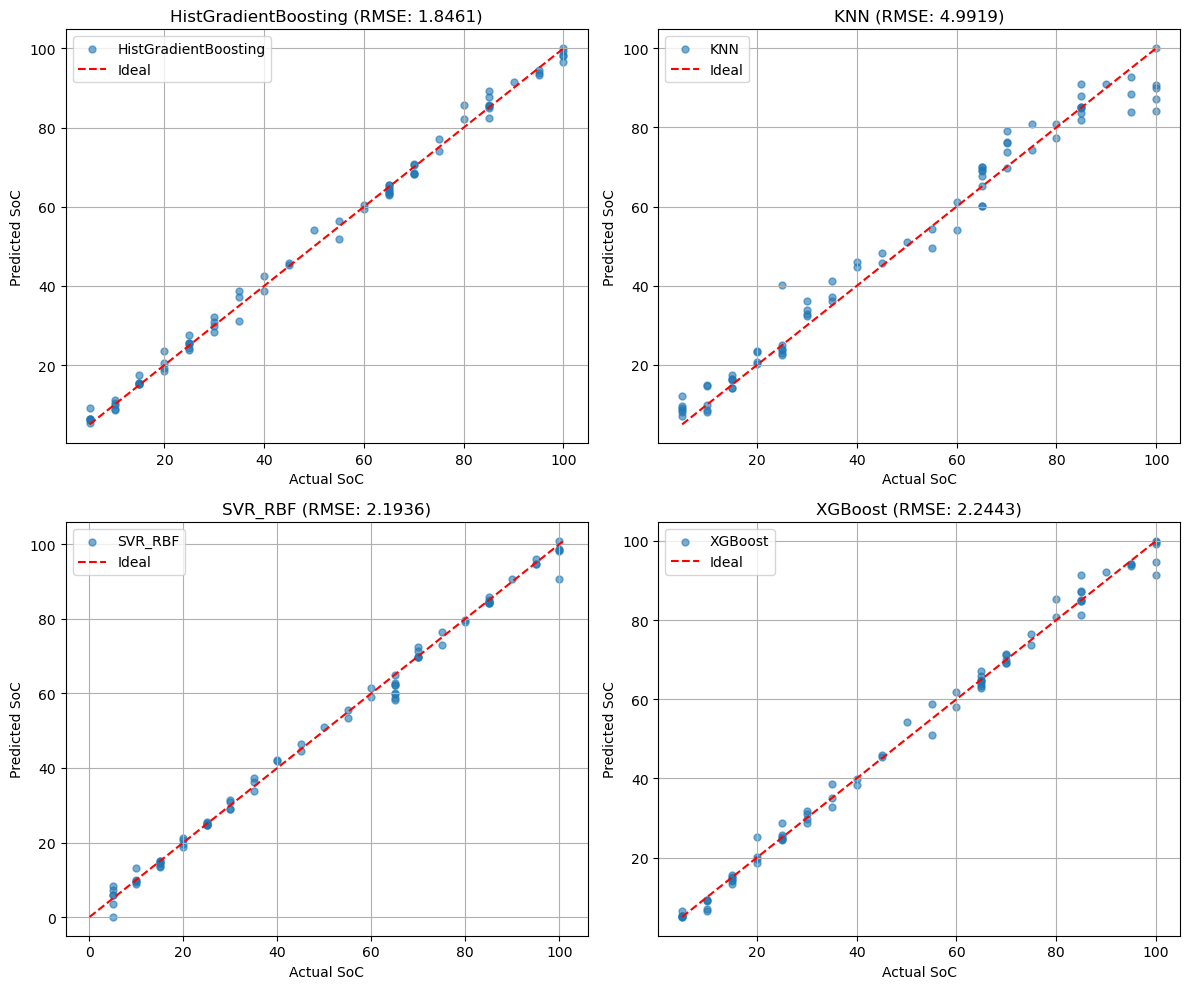

In [23]:
# ACTUAL VS PREDICTED PLOTS FOR NEW MODELS
n_models = len(new_models)
ncols = 2
nrows = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, name in zip(axes, new_models.keys()):
    y_pred = new_predictions[name]
    rmse_val = df_new_results.loc[df_new_results["Model"] == name, "RMSE"].values[0]

    ax.scatter(y_test_spec, y_pred, alpha=0.6, s=25, label=name)

    min_val = min(y_test_spec.min(), y_pred.min())
    max_val = max(y_test_spec.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal')

    ax.set_xlabel("Actual SoC")
    ax.set_ylabel("Predicted SoC")
    ax.set_title(f"{name} (RMSE: {rmse_val:.4f})")
    ax.grid(True)
    ax.legend()

# Hide any unused subplot
for j in range(len(new_models), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("actual vs predicted plot.png",dpi=300,bbox_inches='tight')
plt.show()


In [24]:
!pip install lightgbm


In [25]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

lgbm_model.fit(X_train_spec, y_train_spec)
y_pred_lgbm = lgbm_model.predict(X_test_spec)

# Evaluate
mae_lgbm = mean_absolute_error(y_test_spec, y_pred_lgbm)
mse_lgbm = mean_squared_error(y_test_spec, y_pred_lgbm)
rmse_lgbm = np.sqrt(mse_lgbm)
r2_lgbm = r2_score(y_test_spec, y_pred_lgbm)

print("LightGBM Results:")
print("MAE  =", round(mae_lgbm, 4))
print("MSE  =", round(mse_lgbm, 4))
print("RMSE =", round(rmse_lgbm, 4))
print("R2   =", round(r2_lgbm, 4))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000663 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8568
[LightGBM] [Info] Number of data points in the train set: 304, number of used features: 84
[LightGBM] [Info] Start training from score 53.371711
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [26]:
comparison_df=pd.DataFrame([
    {
        "Model":"HistGradientBoosting",
        "RMSE" : 1.8461,
        "R2"   : 0.9965
    },
    {
        "Model":"LightGBM",
        "RMSE"  : rmse_lgbm,
        "R2" : r2_lgbm
    }
])
comparison_df =comparison_df.sort_values("RMSE").reset_index(drop=True)
print(comparison_df)

                  Model      RMSE        R2
0  HistGradientBoosting  1.846100  0.996500
1              LightGBM  1.920759  0.996167


In [27]:
!pip install catboost

In [28]:
from catboost import CatBoostRegressor

cat_model=CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=5,
    loss_function='RMSE',
    verbose=0,
    random_seed=42
)

cat_model.fit(X_train_spec,y_train_spec)
y_pred_cat=cat_model.predict(X_test_spec)

mae_cat = mean_absolute_error(y_test_spec, y_pred_cat)
mse_cat = mean_squared_error(y_test_spec, y_pred_cat)
rmse_cat = np.sqrt(mse_cat)
r2_cat = r2_score(y_test_spec, y_pred_cat)

print("CatBoost Results:")
print("MAE  =", round(mae_cat, 4))
print("MSE  =", round(mse_cat, 4))
print("RMSE =", round(rmse_cat, 4))
print("R2 =",round(r2_cat,4))



CatBoost Results:
MAE  = 1.6463
MSE  = 4.6059
RMSE = 2.1461
R2 = 0.9952


In [29]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF,ConstantKernel,WhiteKernel
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

gpr_model=Pipeline([
    ('scaler',StandardScaler()),
    ('model',GaussianProcessRegressor(
        kernel=ConstantKernel(1.0)*RBF(length_scale=1.0)+WhiteKernel(noise_level=1e-3),
        alpha=1e-6,
        normalize_y=True
    ))
])

gpr_model.fit(X_train_spec, y_train_spec)
y_pred_gpr = gpr_model.predict(X_test_spec)

mae_gpr = mean_absolute_error(y_test_spec, y_pred_gpr)
mse_gpr = mean_squared_error(y_test_spec, y_pred_gpr)
rmse_gpr = np.sqrt(mse_gpr)
r2_gpr = r2_score(y_test_spec, y_pred_gpr)

print("GPR Results:")
print("MAE  =", round(mae_gpr, 4))
print("MSE  =", round(mse_gpr, 4))
print("RMSE =", round(rmse_gpr, 4))
print("R2  =",round(r2_gpr,4))

GPR Results:
MAE  = 1.1108
MSE  = 3.8137
RMSE = 1.9529
R2  = 0.996


In [30]:
!pip install shap

  Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached numpy-2.0.2-cp312-cp312-win_amd64.whl.metadata (59 kB)
Using cached numpy-2.0.2-cp312-cp312-win_amd64.whl (15.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [31]:
import shap


In [32]:
hgb_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42
)

hgb_model.fit(X_train_spec, y_train_spec)

HistGradientBoostingRegressor(learning_rate=0.05, max_depth=6, max_iter=300,
                              min_samples_leaf=5, random_state=42)

In [33]:
#using shap for feature selection
explainer =shap.Explainer(hgb_model,X_train_spec)
shap_values=explainer(X_test_spec)

In [34]:
shap_importance=pd.DataFrame({
    "Feature":X_test_spec.columns,
    'MeanAbsSHAP':np.abs(shap_values.values).mean(axis=0)
}).sort_values(by='MeanAbsSHAP',ascending=False)

print(shap_importance.head(20))

   Feature  MeanAbsSHAP
5      V_2    13.376755
2      V_1    10.023878
4      X_2     2.308574
1      X_1     0.958316
20     V_7     0.854419
14     V_5     0.830520
26     V_9     0.477345
7      X_3     0.429558
17     V_6     0.403729
23     V_8     0.395271
65    V_22     0.385007
28    X_10     0.230963
8      V_3     0.203832
73    X_25     0.202710
63    R_22     0.097991
70    X_24     0.096750
37    X_13     0.093084
18     R_7     0.074453
69    R_24     0.068896
19     X_7     0.067708


In [35]:
top_features = shap_importance.head(20).copy()

feature_freq_map = []
for feature in top_features["Feature"]:
    var, idx = feature.split("_")
    idx = int(idx)
    freq_value = df_spec.loc[0, f"freq_{idx}"]
    feature_freq_map.append(freq_value)

top_features["Frequency"] = feature_freq_map
print(top_features)

   Feature  MeanAbsSHAP  Frequency
5      V_2    13.376755       0.02
2      V_1    10.023878       0.01
4      X_2     2.308574       0.02
1      X_1     0.958316       0.01
20     V_7     0.854419       0.20
14     V_5     0.830520       0.08
26     V_9     0.477345       0.50
7      X_3     0.429558       0.03
17     V_6     0.403729       0.10
23     V_8     0.395271       0.30
65    V_22     0.385007     100.00
28    X_10     0.230963       0.80
8      V_3     0.203832       0.03
73    X_25     0.202710     310.00
63    R_22     0.097991     100.00
70    X_24     0.096750     210.00
37    X_13     0.093084       3.00
18     R_7     0.074453       0.20
69    R_24     0.068896     210.00
19     X_7     0.067708       0.20


In [36]:
top_features["Type"]=top_features["Feature"].str.split("_").str[0]
print(top_features["Type"].value_counts())

Type
V    9
X    8
R    3
Name: count, dtype: int64


In [37]:
# Select top 20 SHAP features and build new dataset
top20_feature_names = top_features["Feature"].tolist()

X_train_top20 = X_train_spec[top20_feature_names].copy()
X_test_top20 = X_test_spec[top20_feature_names].copy()

print("Original train shape:", X_train_spec.shape)
print("Reduced train shape :", X_train_top20.shape)
print("Original test shape :", X_test_spec.shape)
print("Reduced test shape  :", X_test_top20.shape)

Original train shape: (304, 84)
Reduced train shape : (304, 20)
Original test shape : (76, 84)
Reduced test shape  : (76, 20)


In [38]:
#training hgb boosting with the new dataset
hgb_top20=HistGradientBoostingRegressor(
    max_iter=3000,
    learning_rate=0.05,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42
)
hgb_top20.fit(X_train_top20,y_train_spec)


HistGradientBoostingRegressor(learning_rate=0.05, max_depth=6, max_iter=3000,
                              min_samples_leaf=5, random_state=42)

In [39]:
y_pred_top20 = hgb_top20.predict(X_test_top20)

mae_top20 = mean_absolute_error(y_test_spec, y_pred_top20)
mse_top20 = mean_squared_error(y_test_spec, y_pred_top20)
rmse_top20 = np.sqrt(mse_top20)
r2_top20 = r2_score(y_test_spec, y_pred_top20)

print("HistGB with Top-20 SHAP Features:")
print("MAE  =", round(mae_top20, 4))
print("MSE  =", round(mse_top20, 4))
print("RMSE =", round(rmse_top20, 4))
print("R2   =", round(r2_top20, 4))

HistGB with Top-20 SHAP Features:
MAE  = 1.4945
MSE  = 4.8758
RMSE = 2.2081
R2   = 0.9949


In [40]:
#using 20 top features makes the model worse so lets try with 40 top features
top40_feature_names = shap_importance.head(40)["Feature"].tolist()

X_train_top40 = X_train_spec[top40_feature_names].copy()
X_test_top40 = X_test_spec[top40_feature_names].copy()

print("Train shape:", X_train_top40.shape)
print("Test shape :", X_test_top40.shape)


Train shape: (304, 40)
Test shape : (76, 40)


In [41]:
#training the hgb boosting again with the top 4o features
hgb_top40 = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42
)

hgb_top40.fit(X_train_top40, y_train_spec)
y_pred_top40 = hgb_top40.predict(X_test_top40)

mae_top40 = mean_absolute_error(y_test_spec, y_pred_top40)
mse_top40 = mean_squared_error(y_test_spec, y_pred_top40)
rmse_top40 = np.sqrt(mse_top40)
r2_top40 = r2_score(y_test_spec, y_pred_top40)

print("HistGB with Top-40 SHAP Features:")
print("MAE  =", round(mae_top40, 4))
print("MSE  =", round(mse_top40, 4))
print("RMSE =", round(rmse_top40, 4))
print("R2   =", round(r2_top40, 4))

HistGB with Top-40 SHAP Features:
MAE  = 1.5374
MSE  = 5.8263
RMSE = 2.4138
R2   = 0.9939


In [42]:
#DNN model
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

dnn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        max_iter=2000,
        random_state=42
    ))
])

dnn_model.fit(X_train_spec, y_train_spec)
y_pred_dnn = dnn_model.predict(X_test_spec)

mae_dnn = mean_absolute_error(y_test_spec, y_pred_dnn)
mse_dnn = mean_squared_error(y_test_spec, y_pred_dnn)
rmse_dnn = np.sqrt(mse_dnn)
r2_dnn = r2_score(y_test_spec, y_pred_dnn)

print("DNN Results:")
print("MAE  =", round(mae_dnn, 4))
print("MSE  =", round(mse_dnn, 4))
print("RMSE =", round(rmse_dnn, 4))
print("R2   =", round(r2_dnn, 4))

DNN Results:
MAE  = 1.4565
MSE  = 4.8117
RMSE = 2.1936
R2   = 0.995


In [43]:
#reshaping for CNN 
X_train_cnn = X_train_spec.values.reshape(-1, 28, 3)
X_test_cnn  = X_test_spec.values.reshape(-1, 28, 3)

print("X_train_cnn shape:", X_train_cnn.shape)
print("X_test_cnn shape :", X_test_cnn.shape)

X_train_cnn shape: (304, 28, 3)
X_test_cnn shape : (76, 28, 3)


In [44]:
!pip install tensorflow

In [45]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

cnn_model = Sequential([
    Input(shape=(28, 3)),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1)
])

cnn_model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = cnn_model.fit(
    X_train_cnn, y_train_spec,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

y_pred_cnn = cnn_model.predict(X_test_cnn).flatten()

mae_cnn = mean_absolute_error(y_test_spec, y_pred_cnn)
mse_cnn = mean_squared_error(y_test_spec, y_pred_cnn)
rmse_cnn = np.sqrt(mse_cnn)
r2_cnn = r2_score(y_test_spec, y_pred_cnn)

print("CNN Results:")
print("MAE  =", round(mae_cnn, 4))
print("MSE  =", round(mse_cnn, 4))
print("RMSE =", round(rmse_cnn, 4))
print("R2   =", round(r2_cnn, 4))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
CNN Results:
MAE  = 22.5401
MSE  = 642.4357
RMSE = 25.3463
R2   = 0.3325


In [46]:
from sklearn.preprocessing import StandardScaler

# scale flat features first
scaler_seq = StandardScaler()
X_train_scaled = scaler_seq.fit_transform(X_train_spec)
X_test_scaled = scaler_seq.transform(X_test_spec)

X_train_lstm = X_train_scaled.reshape(-1, 28, 3)
X_test_lstm = X_test_scaled.reshape(-1, 28, 3)

print("X_train_lstm shape:", X_train_lstm.shape)
print("X_test_lstm shape :", X_test_lstm.shape)

X_train_lstm shape: (304, 28, 3)
X_test_lstm shape : (76, 28, 3)


In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tf.random.set_seed(42)

lstm_model = Sequential([
    Input(shape=(28, 3)),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm, y_train_spec,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

y_pred_lstm = lstm_model.predict(X_test_lstm).flatten()

mae_lstm = mean_absolute_error(y_test_spec, y_pred_lstm)
mse_lstm = mean_squared_error(y_test_spec, y_pred_lstm)
rmse_lstm = np.sqrt(mse_lstm)
r2_lstm = r2_score(y_test_spec, y_pred_lstm)

print("LSTM Results:")
print("MAE  =", round(mae_lstm, 4))
print("MSE  =", round(mse_lstm, 4))
print("RMSE =", round(rmse_lstm, 4))
print("R2   =", round(r2_lstm, 4))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
LSTM Results:
MAE  = 6.0524
MSE  = 64.9012
RMSE = 8.0561
R2   = 0.9326


In [48]:
#tuning lightbgm
from lightgbm import LGBMRegressor

param_list = [
    {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 4},
    {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 5},
    {"n_estimators": 500, "learning_rate": 0.03, "max_depth": 5},
    {"n_estimators": 400, "learning_rate": 0.03, "max_depth": 6},
    {"n_estimators": 500, "learning_rate": 0.02, "max_depth": 6}
]

tuning_results = []

for params in param_list:
    model = LGBMRegressor(
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        random_state=42,
        verbose=-1
    )
    
    model.fit(X_train_spec, y_train_spec)
    y_pred = model.predict(X_test_spec)
    
    mae = mean_absolute_error(y_test_spec, y_pred)
    mse = mean_squared_error(y_test_spec, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_spec, y_pred)
    
    tuning_results.append({
        "n_estimators": params["n_estimators"],
        "learning_rate": params["learning_rate"],
        "max_depth": params["max_depth"],
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

tuning_df = pd.DataFrame(tuning_results).sort_values("RMSE").reset_index(drop=True)
print(tuning_df.round(4))

   n_estimators  learning_rate  max_depth     MAE    RMSE      R2
0           500           0.03          5  1.4703  1.8854  0.9963
1           300           0.05          5  1.4966  1.9208  0.9962
2           400           0.03          6  1.5128  1.9414  0.9961
3           500           0.02          6  1.5554  2.0183  0.9958
4           200           0.05          4  1.5585  2.0642  0.9956


In [49]:
#tuning HIstGBR
from sklearn.ensemble import HistGradientBoostingRegressor
param_list_hgb = [
    {"max_iter": 200, "learning_rate": 0.05, "max_depth": 4, "min_samples_leaf": 5},
    {"max_iter": 300, "learning_rate": 0.05, "max_depth": 6, "min_samples_leaf": 5},
    {"max_iter": 500, "learning_rate": 0.03, "max_depth": 5, "min_samples_leaf": 5},
    {"max_iter": 400, "learning_rate": 0.03, "max_depth": 6, "min_samples_leaf": 3},
    {"max_iter": 500, "learning_rate": 0.02, "max_depth": 6, "min_samples_leaf": 3}
]

tuning_results_hgb = []

for params in param_list_hgb:
    model = HistGradientBoostingRegressor(
        max_iter=params["max_iter"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        min_samples_leaf=params["min_samples_leaf"],
        random_state=42
    )
    
    model.fit(X_train_spec, y_train_spec)
    y_pred = model.predict(X_test_spec)
    
    mae = mean_absolute_error(y_test_spec, y_pred)
    mse = mean_squared_error(y_test_spec, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_spec, y_pred)
    
    tuning_results_hgb.append({
        "max_iter": params["max_iter"],
        "learning_rate": params["learning_rate"],
        "max_depth": params["max_depth"],
        "min_samples_leaf": params["min_samples_leaf"],
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

tuning_hgb_df = pd.DataFrame(tuning_results_hgb).sort_values("RMSE").reset_index(drop=True)
print(tuning_hgb_df.round(4))

   max_iter  learning_rate  max_depth  min_samples_leaf     MAE    RMSE  \
0       200           0.05          4                 5  1.6331  2.2802   
1       500           0.03          5                 5  1.6987  2.3710   
2       400           0.03          6                 3  1.7606  2.5529   
3       500           0.02          6                 3  1.7812  2.5725   
4       300           0.05          6                 5  1.8395  2.6063   

       R2  
0  0.9946  
1  0.9942  
2  0.9932  
3  0.9931  
4  0.9929  


In [50]:
comparison_final = pd.DataFrame([
    {"Model": "HistGradientBoosting (best earlier)", "RMSE": 1.8461, "R2": 0.9965},
    {"Model": "LightGBM (best tuned)",              "RMSE": 1.8854, "R2": 0.9963},
    {"Model": "LightGBM (plain)",                   "RMSE": 1.9208, "R2": 0.9962},
    {"Model": "GPR",                                "RMSE": 1.9529, "R2": 0.9960},
    {"Model": "CatBoost",                           "RMSE": 2.1461, "R2": 0.9952},
    {"Model": "DNN (MLPRegressor)",                 "RMSE": 2.1936, "R2": 0.9950},
    {"Model": "HistGB + Top20 SHAP",                "RMSE": 2.2081, "R2": 0.9949},
    {"Model": "HistGB + Top40 SHAP",                "RMSE": 2.4138, "R2": 0.9939},
    {"Model": "LSTM",                               "RMSE": 4.1593, "R2": 0.9820},
    {"Model": "CNN",                                "RMSE": 28.9701,"R2": 0.1280}
])

comparison_final = comparison_final.sort_values("RMSE").reset_index(drop=True)
print("final MOdel coparison table",comparison_final)

final MOdel coparison table                                  Model     RMSE      R2
0  HistGradientBoosting (best earlier)   1.8461  0.9965
1                LightGBM (best tuned)   1.8854  0.9963
2                     LightGBM (plain)   1.9208  0.9962
3                                  GPR   1.9529  0.9960
4                             CatBoost   2.1461  0.9952
5                   DNN (MLPRegressor)   2.1936  0.9950
6                  HistGB + Top20 SHAP   2.2081  0.9949
7                  HistGB + Top40 SHAP   2.4138  0.9939
8                                 LSTM   4.1593  0.9820
9                                  CNN  28.9701  0.1280


In [51]:
#using randomize....to find the best parameter for lgbm..similar to aso method

from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd

lgbm_base = LGBMRegressor(random_state=42, verbose=-1)

param_dist = {
    "n_estimators": [200, 300, 400, 500, 700, 900],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.07],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "num_leaves": [15, 31, 45, 63, 80],
    "min_child_samples": [5, 10, 15, 20, 25],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_dist,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=1,
    verbose=1
)

random_search.fit(X_spec, y_spec)

print("Best Params:")
print(random_search.best_params_)

print("\nBest CV RMSE:")
print(-random_search.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Params:
{'subsample': 0.8, 'num_leaves': 45, 'n_estimators': 400, 'min_child_samples': 10, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

Best CV RMSE:
11.18475827470352


In [52]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold

lgbm_base = LGBMRegressor(random_state=42, verbose=-1)

param_dist = {
    "n_estimators": [200, 300, 400, 500, 700, 900],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.07],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "num_leaves": [15, 31, 45, 63, 80],
    "min_child_samples": [5, 10, 15, 20, 25],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_dist,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=1
)

random_search.fit(X_spec, y_spec)

print("Best Params:")
print(random_search.best_params_)

print("\nBest CV RMSE:")
print(-random_search.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Params:
{'subsample': 1.0, 'num_leaves': 15, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': 5, 'learning_rate': 0.07, 'colsample_bytree': 0.7}

Best CV RMSE:
1.768954658535447


In [53]:
#as we find the best parameter using hyperparameter tuning..now lets use them to train the model again
from lightgbm import LGBMRegressor

best_lgbm = LGBMRegressor(
    subsample=1.0,
    num_leaves=15,
    n_estimators=500,
    min_child_samples=20,
    max_depth=5,
    learning_rate=0.07,
    colsample_bytree=0.7,
    random_state=42,
    verbose=-1
)

best_lgbm.fit(X_train_spec, y_train_spec)
y_pred_best_lgbm = best_lgbm.predict(X_test_spec)

mae_best_lgbm = mean_absolute_error(y_test_spec, y_pred_best_lgbm)
mse_best_lgbm = mean_squared_error(y_test_spec, y_pred_best_lgbm)
rmse_best_lgbm = np.sqrt(mse_best_lgbm)
r2_best_lgbm = r2_score(y_test_spec, y_pred_best_lgbm)

print("Optimized LightGBM Test Results:")
print("MAE  =", round(mae_best_lgbm, 4))
print("MSE  =", round(mse_best_lgbm, 4))
print("RMSE =", round(rmse_best_lgbm, 4))
print("R2   =", round(r2_best_lgbm, 4))

Optimized LightGBM Test Results:
MAE  = 1.396
MSE  = 3.2499
RMSE = 1.8027
R2   = 0.9966


In [128]:
# 1. Final comparison table
comparison_final = pd.DataFrame([
    {"Model": "Optimized LightGBM",           "RMSE": rmse_best_lgbm, "R2": r2_best_lgbm},
    {"Model": "HistGradientBoosting",         "RMSE": 1.8461,        "R2": 0.9965},
    {"Model": "LightGBM (manual tuned)",      "RMSE": tuning_df.iloc[0]["RMSE"], "R2": tuning_df.iloc[0]["R2"]},
    {"Model": "LightGBM (plain)",             "RMSE": rmse_lgbm,     "R2": r2_lgbm},
    {"Model": "GPR",                          "RMSE": rmse_gpr,      "R2": r2_gpr},
    {"Model": "CatBoost",                     "RMSE": rmse_cat,      "R2": r2_cat},
    {"Model": "DNN (MLPRegressor)",           "RMSE": rmse_dnn,      "R2": r2_dnn},
    {"Model": "HistGB + Top20 SHAP",          "RMSE": rmse_top20,    "R2": r2_top20},
    {"Model": "HistGB + Top40 SHAP",          "RMSE": rmse_top40,    "R2": r2_top40},
    {"Model": "LSTM",                         "RMSE": rmse_lstm,     "R2": r2_lstm},
    {"Model": "CNN",                          "RMSE": rmse_cnn,      "R2": r2_cnn},
    {"Model": "Transformer", "RMSE": rmse_transformer, "R2": r2_transformer}
])

comparison_final = comparison_final.sort_values("RMSE").reset_index(drop=True)
print(comparison_final.round(4))

# Save table
comparison_final.to_csv("final_model_comparison_table.csv", index=False)


                      Model     RMSE      R2
0        Optimized LightGBM   1.8027  0.9966
1      HistGradientBoosting   1.8461  0.9965
2   LightGBM (manual tuned)   1.8854  0.9963
3          LightGBM (plain)   1.9208  0.9962
4                       GPR   1.9529  0.9960
5                  CatBoost   2.1461  0.9952
6        DNN (MLPRegressor)   2.1936  0.9950
7       HistGB + Top20 SHAP   2.2081  0.9949
8       HistGB + Top40 SHAP   2.4138  0.9939
9                      LSTM   8.0561  0.9326
10              Transformer  16.0177  0.7334
11                      CNN  25.3463  0.3325


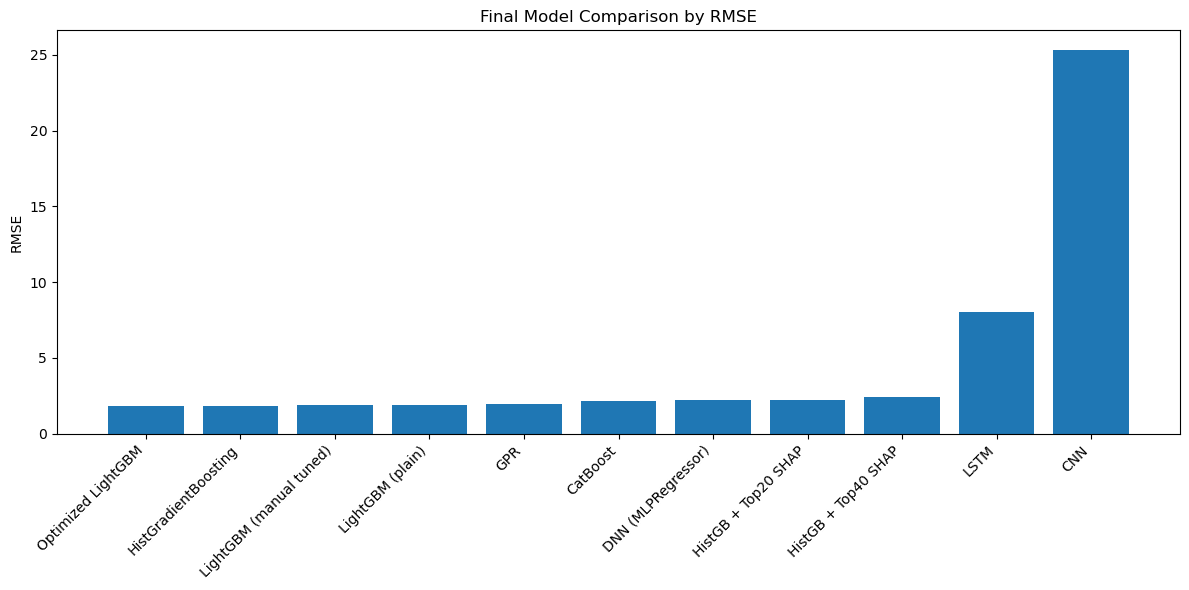

In [55]:
# 2. RMSE bar chart
plt.figure(figsize=(12, 6))
plt.bar(comparison_final["Model"], comparison_final["RMSE"])
plt.xticks(rotation=45, ha='right')
plt.ylabel("RMSE")
plt.title("Final Model Comparison by RMSE")
plt.tight_layout()
plt.savefig("final_model_rmse_bar.png", dpi=300, bbox_inches="tight")
plt.show()



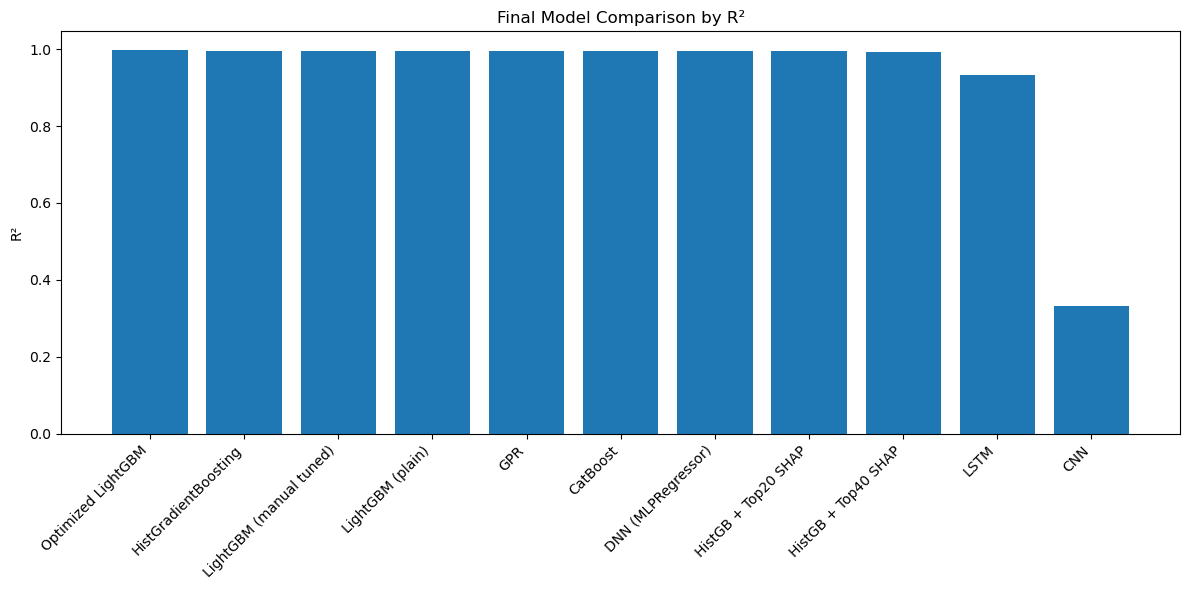

In [56]:

# 3. R2 bar chart
plt.figure(figsize=(12, 6))
plt.bar(comparison_final["Model"], comparison_final["R2"])
plt.xticks(rotation=45, ha='right')
plt.ylabel("R²")
plt.title("Final Model Comparison by R²")
plt.tight_layout()
plt.savefig("final_model_r2_bar.png", dpi=300, bbox_inches="tight")
plt.show()

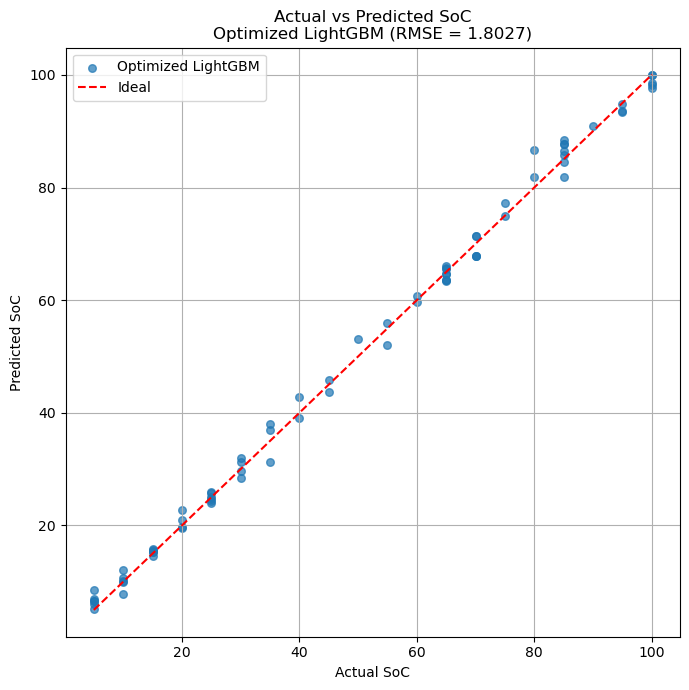

In [57]:
# 4. Actual vs Predicted for best model
plt.figure(figsize=(7, 7))
plt.scatter(y_test_spec, y_pred_best_lgbm, alpha=0.7, s=30, label="Optimized LightGBM")

min_val = min(y_test_spec.min(), y_pred_best_lgbm.min())
max_val = max(y_test_spec.max(), y_pred_best_lgbm.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Ideal")
plt.xlabel("Actual SoC")
plt.ylabel("Predicted SoC")
plt.title(f"Actual vs Predicted SoC\nOptimized LightGBM (RMSE = {rmse_best_lgbm:.4f})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("optimized_lightgbm_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

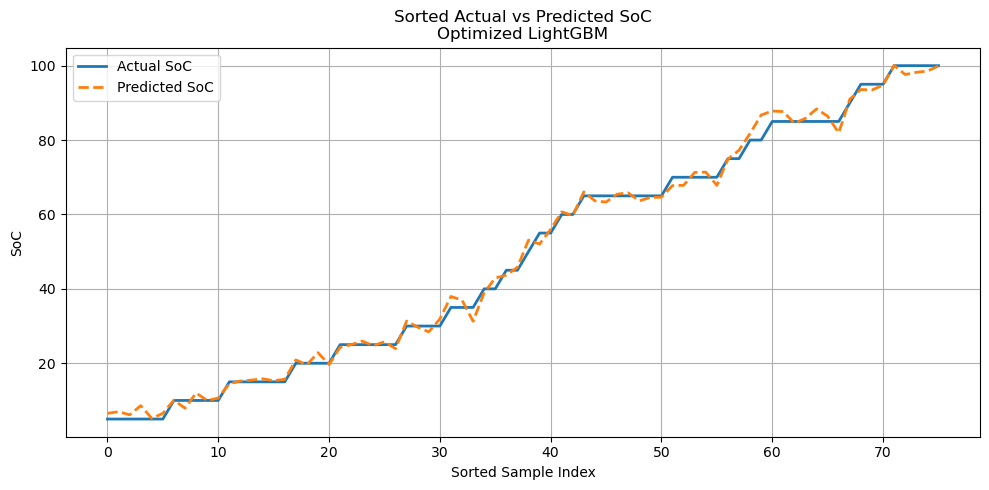

In [58]:
# 5. Sorted line comparison for best model
sorted_idx = np.argsort(y_test_spec.values)
y_true_sorted = y_test_spec.values[sorted_idx]
y_pred_sorted = y_pred_best_lgbm[sorted_idx]

plt.figure(figsize=(10, 5))
plt.plot(y_true_sorted, label="Actual SoC", linewidth=2)
plt.plot(y_pred_sorted, label="Predicted SoC", linestyle="--", linewidth=2)
plt.xlabel("Sorted Sample Index")
plt.ylabel("SoC")
plt.title("Sorted Actual vs Predicted SoC\nOptimized LightGBM")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("optimized_lightgbm_sorted_line.png", dpi=300, bbox_inches="tight")
plt.show()

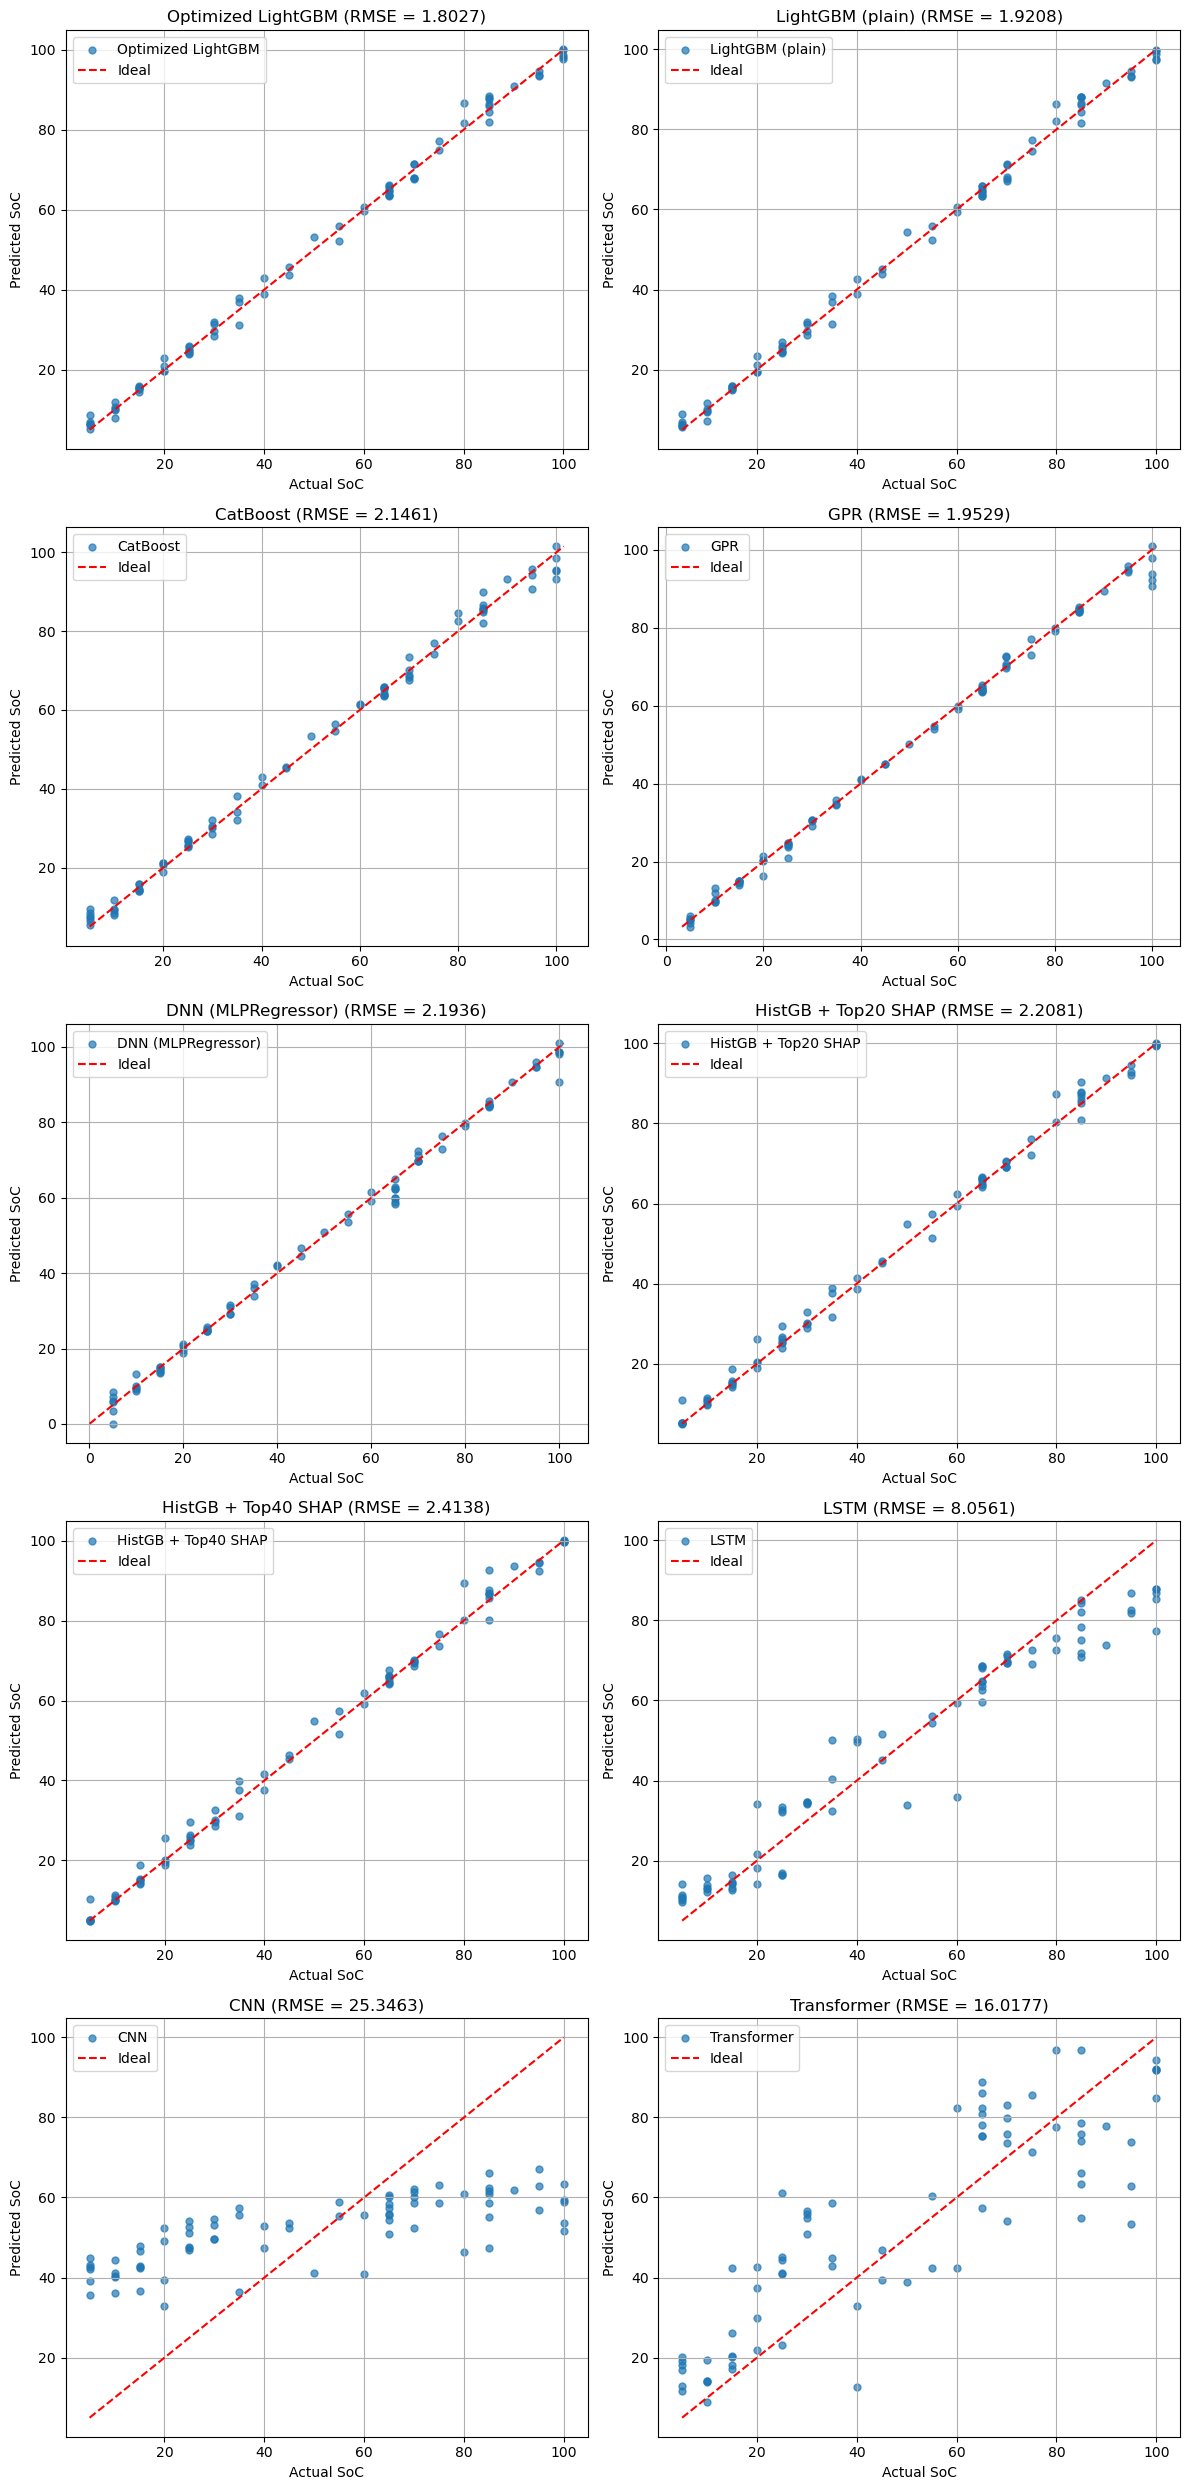

In [130]:
import matplotlib.pyplot as plt
import numpy as np

pred_dict = {
    "Optimized LightGBM": y_pred_best_lgbm,
    "LightGBM (plain)": y_pred_lgbm,
    "CatBoost": y_pred_cat,
    "GPR": y_pred_gpr,
    "DNN (MLPRegressor)": y_pred_dnn,
    "HistGB + Top20 SHAP": y_pred_top20,
    "HistGB + Top40 SHAP": y_pred_top40,
    "LSTM": y_pred_lstm,
    "CNN": y_pred_cnn,
    "Transformer": y_pred_transformer
}

n_models = len(pred_dict)
ncols = 2
nrows = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, (name, y_pred) in zip(axes, pred_dict.items()):
    rmse_val = np.sqrt(np.mean((y_test_spec - y_pred) ** 2))

    ax.scatter(y_test_spec, y_pred, alpha=0.7, s=25, label=name)

    min_val = min(y_test_spec.min(), y_pred.min())
    max_val = max(y_test_spec.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal')

    ax.set_xlabel("Actual SoC")
    ax.set_ylabel("Predicted SoC")
    ax.set_title(f"{name} (RMSE = {rmse_val:.4f})")
    ax.grid(True)
    ax.legend()

# Hide empty subplots
for i in range(len(pred_dict), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("all_models_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

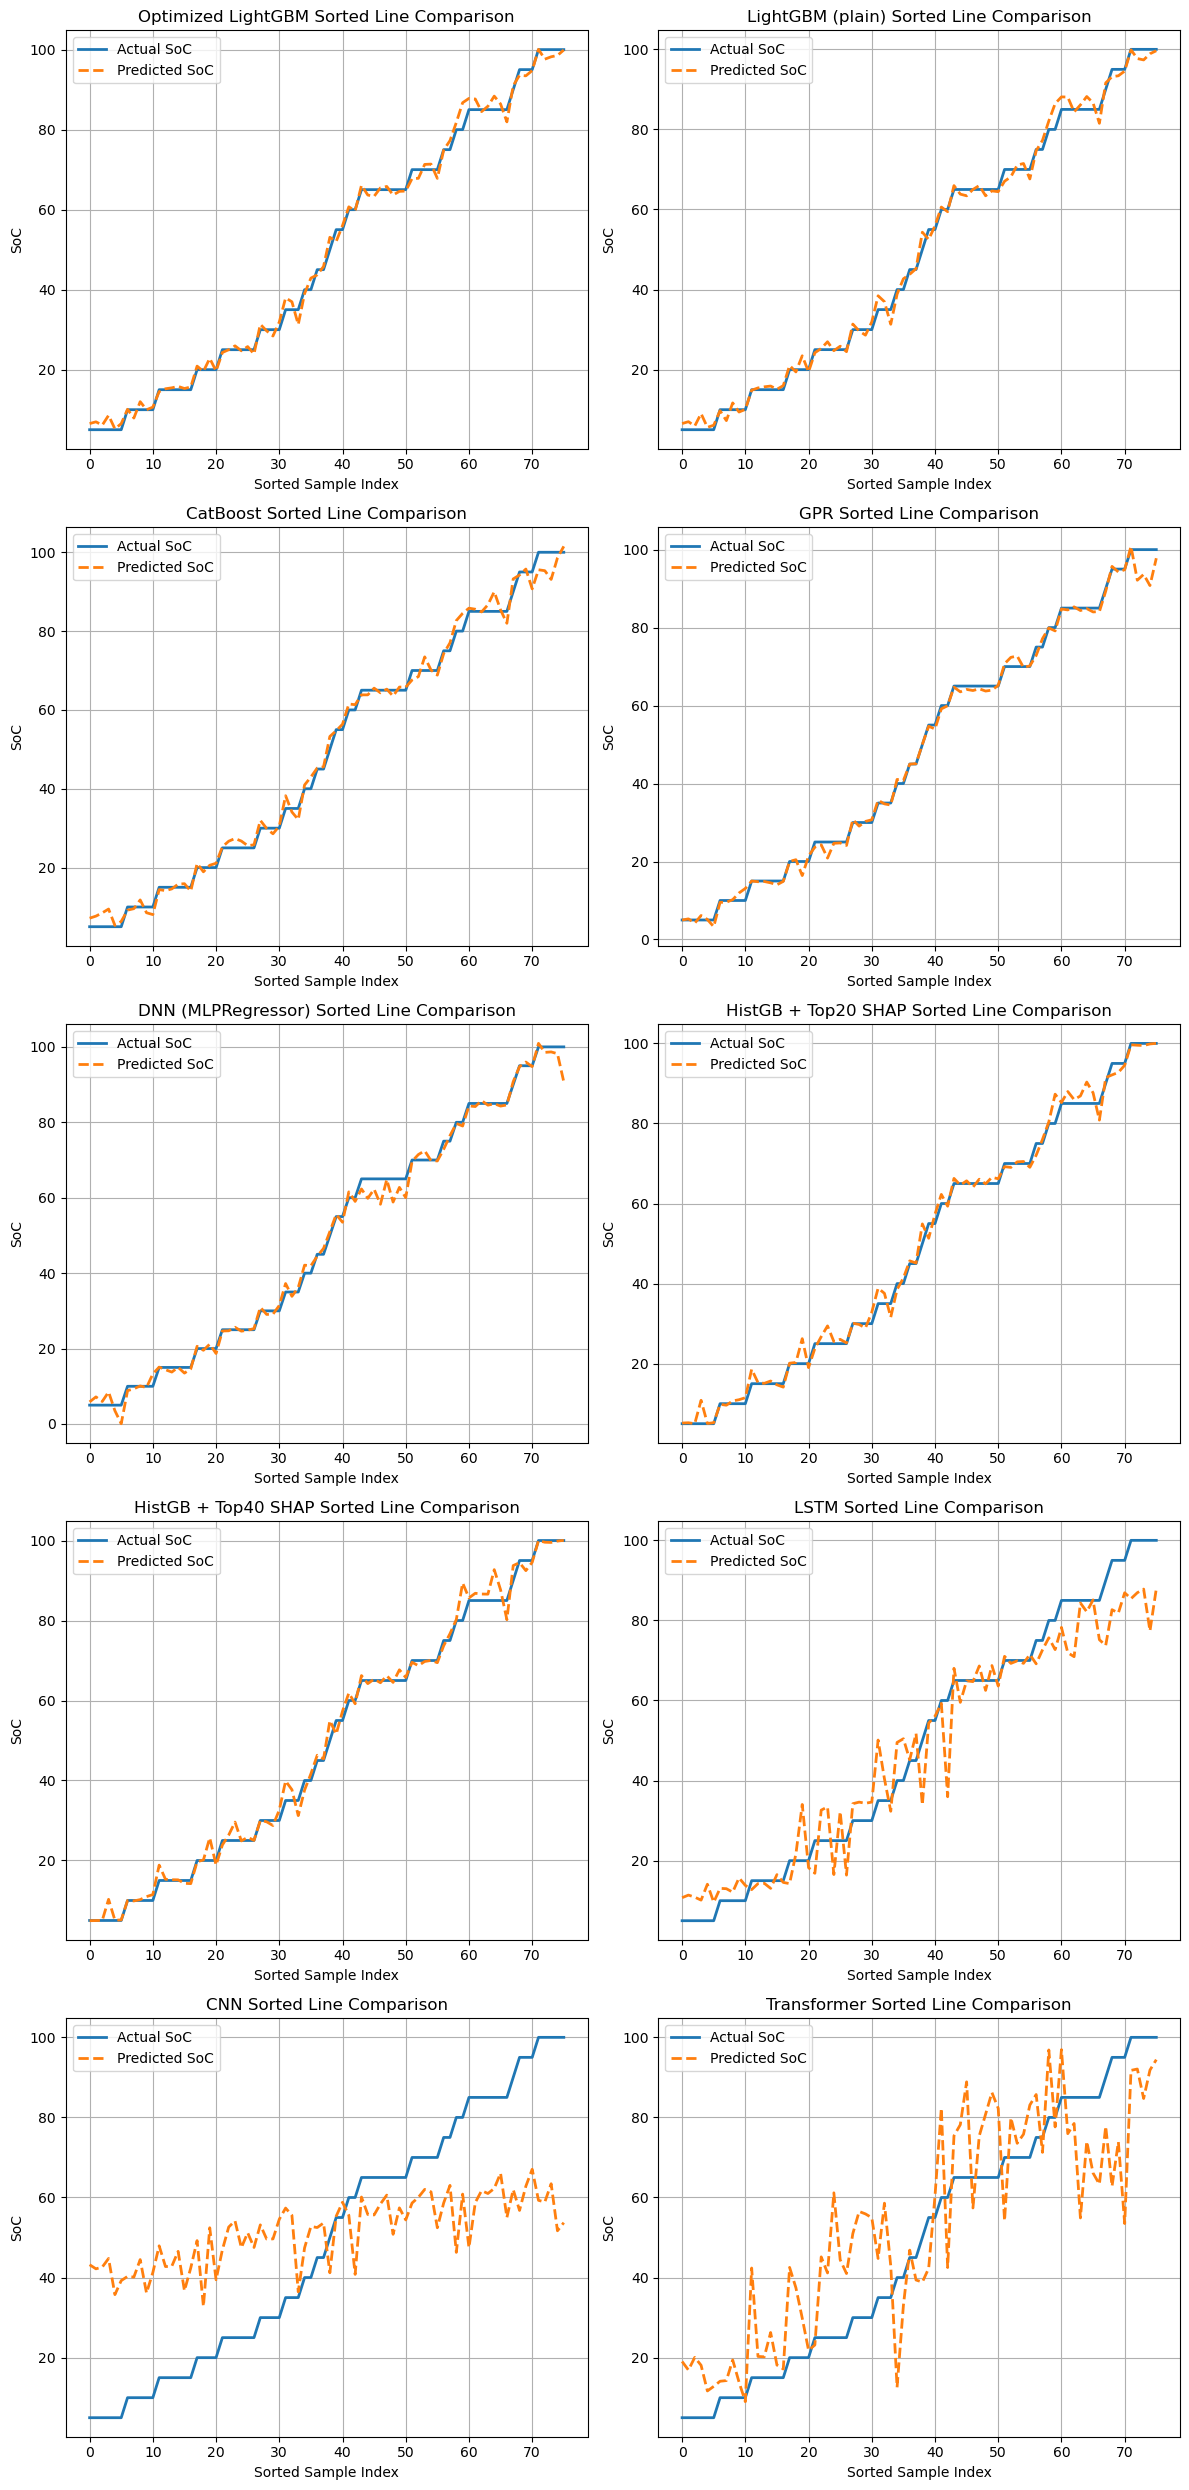

In [132]:
import matplotlib.pyplot as plt
import numpy as np

sorted_idx = np.argsort(y_test_spec.values)
y_true_sorted = y_test_spec.values[sorted_idx]

n_models = len(pred_dict)
ncols = 2
nrows = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, (name, y_pred) in zip(axes, pred_dict.items()):
    y_pred_sorted = y_pred[sorted_idx]

    ax.plot(y_true_sorted, label="Actual SoC", linewidth=2)
    ax.plot(y_pred_sorted, label="Predicted SoC", linestyle="--", linewidth=2)

    ax.set_xlabel("Sorted Sample Index")
    ax.set_ylabel("SoC")
    ax.set_title(f"{name} Sorted Line Comparison")
    ax.grid(True)
    ax.legend()

# Hide empty subplots
for i in range(len(pred_dict), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("all_models_sorted_line_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [61]:
print(np.__version__)

1.26.4


In [62]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization
from tensorflow.keras.layers import MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(x, x)
    x = Dropout(dropout)(x)
    res = x + inputs

    x = LayerNormalization(epsilon=1e-6)(res)
    x = Dense(ff_dim, activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    return x + res



In [63]:
# ----- Input -----
inputs = Input(shape=(28, 3))

x = transformer_encoder(inputs, head_size=32, num_heads=2, ff_dim=64, dropout=0.1)
x = transformer_encoder(x, head_size=32, num_heads=2, ff_dim=64, dropout=0.1)

x = GlobalAveragePooling1D()(x)
x = Dense(32, activation="relu")(x)
x = Dropout(0.1)(x)
outputs = Dense(1)(x)

transformer_model = Model(inputs, outputs)

transformer_model.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history = transformer_model.fit(
    X_train_lstm, y_train_spec,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

y_pred_transformer = transformer_model.predict(X_test_lstm).flatten()

mae_transformer = mean_absolute_error(y_test_spec, y_pred_transformer)
mse_transformer = mean_squared_error(y_test_spec, y_pred_transformer)
rmse_transformer = np.sqrt(mse_transformer)
r2_transformer = r2_score(y_test_spec, y_pred_transformer)

print("Transformer Results:")
print("MAE  =", round(mae_transformer, 4))
print("MSE  =", round(mse_transformer, 4))
print("RMSE =", round(rmse_transformer, 4))
print("R2   =", round(r2_transformer, 4))


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002D1000AC220> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Transformer Results:
MAE  = 13.4308
MSE  = 256.5658
RMSE = 16.0177
R2   = 0.7334
